# Project 29 — Hotel Revenue & Cancellation Intelligence

## Cancellation-risk scoring, revenue-at-risk analytics and intervention economics

This project turns hotel reservation data into a **revenue-management decision system** rather than a generic classification exercise.

**Business question:** Which bookings are most likely to cancel, how much booking value is exposed, and how should a revenue team prioritise interventions?

### What this notebook demonstrates
- real hotel reservation data
- commercial KPI construction
- deterministic train/validation/test splitting
- feature engineering for booking behaviour
- a custom logistic-regression classifier built from first principles
- probability calibration with Platt scaling
- validation-based threshold selection
- ROC-AUC, PR-AUC, F1, Brier score and calibration analysis
- risk-decile / lift analysis
- segment and lead-time diagnostics
- coefficient-based interpretability
- an explicit intervention-value scenario
- integrity checks and limitations

> The intervention economics are a **scenario**, not a causal claim about what a hotel would actually recover.

## 1. Reproducibility and data provenance

The fixed modelling file is a **7,255-booking held-out split** from a public GitHub mirror of the Ahsan81/Kaggle Hotel Reservations classification dataset.

The broader public dataset contains 36,275 reservations. This project intentionally pins a fixed 7,255-row file so the GitHub notebook is reproducible and the saved results do not move if an upstream dataset changes.

Before commercial redistribution, verify the original dataset licence and provenance.

In [ ]:
import math
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 2026
np.set_printoptions(suppress=True, precision=4)
pd.set_option("display.max_columns", 60)
print("Reproducibility seed:", SEED)

Reproducibility seed: 2026

In [ ]:
DATA_URL = (
    "https://raw.githubusercontent.com/BlueDoze/"
    "MLOps-Project-LightGBM-Model/main/artifacts/raw/test.csv"
)

df = pd.read_csv(DATA_URL)
print("Shape:", df.shape)
print("Columns:", len(df.columns))
print("Target values:")
print(df["booking_status"].value_counts())

Shape: (7255, 19)
Columns: 19
Target values:
booking_status
Not_Canceled    4839
Canceled        2416
Name: count, dtype: int64

## 2. Data-quality and commercial exposure audit

In [ ]:
audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "unique": df.nunique(),
})
print("Duplicate rows:", int(df.duplicated().sum()))
print("Missing cells:", int(df.isna().sum().sum()))
display(audit)

df["total_nights"] = df["no_of_weekend_nights"] + df["no_of_week_nights"]
df["booking_value_proxy"] = (
    df["avg_price_per_room"] * df["total_nights"].clip(lower=1)
)
df["is_canceled"] = df["booking_status"].eq("Canceled").astype(int)

gross_value = df["booking_value_proxy"].sum()
canceled_value = df.loc[df["is_canceled"].eq(1), "booking_value_proxy"].sum()

print(f"Cancellation rate: {df['is_canceled'].mean():.1%}")
print(f"Gross booking-value proxy: {gross_value:,.2f} CU")
print(f"Canceled booking-value proxy: {canceled_value:,.2f} CU")
print(f"Canceled-value share: {canceled_value/gross_value:.1%}")

Duplicate rows: 0
Missing cells: 0
Cancellation rate: 33.3%
Gross booking-value proxy: 2,278,903.35 CU
Canceled booking-value proxy: 873,707.81 CU
Canceled-value share: 38.3%

**Interpretation:** one third of reservations cancel in this fixed sample, but those canceled reservations represent an even larger share of the booking-value proxy. That makes cancellation prioritisation a revenue-management problem, not only a classification problem.

## 3. Lead-time risk — first operational signal

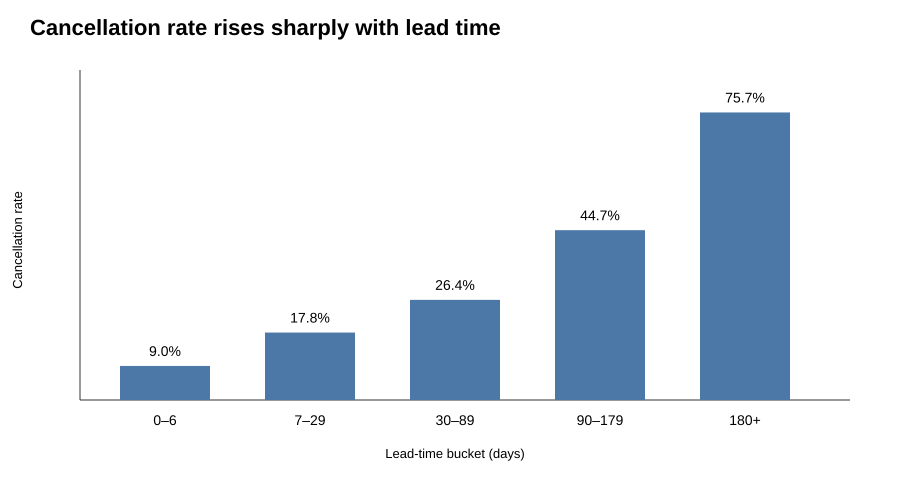

In [ ]:
def lead_bucket(days):
    if days < 7:
        return "0-6"
    if days < 30:
        return "7-29"
    if days < 90:
        return "30-89"
    if days < 180:
        return "90-179"
    return "180+"

df["lead_bucket"] = df["lead_time"].map(lead_bucket)
lead_order = ["0-6", "7-29", "30-89", "90-179", "180+"]

lead_profile = (
    df.groupby("lead_bucket", observed=False)
      .agg(bookings=("Booking_ID", "size"),
           cancellation_rate=("is_canceled", "mean"),
           gross_value=("booking_value_proxy", "sum"))
      .reindex(lead_order)
)

display(lead_profile.round(4))

lead_profile["cancellation_rate"].plot(kind="bar", figsize=(9, 4))
plt.ylabel("Cancellation rate")
plt.title("Cancellation rate by booking lead time")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
market_profile = (
    df.groupby("market_segment_type")
      .agg(bookings=("Booking_ID", "size"),
           cancellation_rate=("is_canceled", "mean"),
           gross_value=("booking_value_proxy", "sum"))
      .sort_values("cancellation_rate", ascending=False)
)
display(market_profile.round(4))

market_segment_type  bookings  cancellation_rate  gross_value
Aviation                  29             0.3793      11065.00
Online                  4664             0.3703    1653613.11
Offline                 2098             0.3036     550153.22
Corporate                385             0.1065      63311.02
Complementary             79             0.0000        761.00

## 4. Leakage-safe feature engineering

The model uses only information that would plausibly be available before the final booking outcome.

We exclude:
- `Booking_ID` as an identifier
- `booking_status` as the target
- any feature calculated from the future outcome

We add commercial features such as total nights, party size, booking-value proxy, historical cancellation ratio, log lead time, price per person and cyclical month encoding.

In [ ]:
NUMERIC_FEATURES = [
    "no_of_adults", "no_of_children", "no_of_weekend_nights",
    "no_of_week_nights", "required_car_parking_space", "lead_time",
    "arrival_year", "arrival_month", "arrival_date", "repeated_guest",
    "no_of_previous_cancellations",
    "no_of_previous_bookings_not_canceled",
    "avg_price_per_room", "no_of_special_requests",
    "total_nights", "party_size", "booking_value",
    "prior_cancel_rate", "lead_time_log", "price_per_person",
    "month_sin", "month_cos",
]

CATEGORICAL_FEATURES = [
    "type_of_meal_plan",
    "room_type_reserved",
    "market_segment_type",
]

def engineered_numeric(row):
    adults = float(row["no_of_adults"])
    children = float(row["no_of_children"])
    weekend = float(row["no_of_weekend_nights"])
    weekday = float(row["no_of_week_nights"])
    nights = weekend + weekday
    party = adults + children
    price = float(row["avg_price_per_room"])
    prior_c = float(row["no_of_previous_cancellations"])
    prior_nc = float(row["no_of_previous_bookings_not_canceled"])
    month = float(row["arrival_month"])

    return [
        adults, children, weekend, weekday,
        float(row["required_car_parking_space"]),
        float(row["lead_time"]),
        float(row["arrival_year"]),
        month,
        float(row["arrival_date"]),
        float(row["repeated_guest"]),
        prior_c,
        prior_nc,
        price,
        float(row["no_of_special_requests"]),
        nights,
        party,
        price * max(nights, 1.0),
        prior_c / (prior_c + prior_nc + 1.0),
        math.log1p(float(row["lead_time"])),
        price / max(party, 1.0),
        math.sin(2 * math.pi * month / 12.0),
        math.cos(2 * math.pi * month / 12.0),
    ]

## 5. Deterministic stratified split

A small custom linear-congruential generator is used so the exact split can be reproduced across environments without relying on library-specific shuffling behaviour.

In [ ]:
def lcg(seed):
    state = int(seed) & 0xFFFFFFFF
    while True:
        state = (1664525 * state + 1013904223) & 0xFFFFFFFF
        yield state / 2**32

def deterministic_shuffle(indices, seed):
    out = list(indices)
    rng = lcg(seed)
    for i in range(len(out) - 1, 0, -1):
        j = int(next(rng) * (i + 1))
        out[i], out[j] = out[j], out[i]
    return out

positive_idx = deterministic_shuffle(
    df.index[df["is_canceled"].eq(1)].tolist(), 2026
)
negative_idx = deterministic_shuffle(
    df.index[df["is_canceled"].eq(0)].tolist(), 2027
)

def split_class(indices):
    n = len(indices)
    n_train = int(np.floor(0.60 * n))
    n_val = int(np.floor(0.20 * n))
    return (
        indices[:n_train],
        indices[n_train:n_train+n_val],
        indices[n_train+n_val:],
    )

ptr, pval, ptest = split_class(positive_idx)
ntr, nval, ntest = split_class(negative_idx)

train_idx = deterministic_shuffle(ptr + ntr, 3030)
val_idx = deterministic_shuffle(pval + nval, 3031)
test_idx = deterministic_shuffle(ptest + ntest, 3032)

train_df = df.loc[train_idx].reset_index(drop=True)
val_df = df.loc[val_idx].reset_index(drop=True)
test_df = df.loc[test_idx].reset_index(drop=True)

for name, part in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    print(name, len(part), f"cancel_rate={part['is_canceled'].mean():.4f}")

train 4352 cancel_rate=0.3330
validation 1450 cancel_rate=0.3331
test 1453 cancel_rate=0.3331

## 6. One-hot encoding and standardisation

In [ ]:
CATEGORY_LEVELS = {
    col: sorted(train_df[col].astype(str).unique().tolist())
    for col in CATEGORICAL_FEATURES
}

DUMMY_FEATURES = [
    f"{col}={level}"
    for col in CATEGORICAL_FEATURES
    for level in CATEGORY_LEVELS[col][1:]
]

FEATURE_NAMES = NUMERIC_FEATURES + DUMMY_FEATURES

def raw_feature_vector(row):
    x = engineered_numeric(row)

    for col in CATEGORICAL_FEATURES:
        levels = CATEGORY_LEVELS[col]
        for level in levels[1:]:
            x.append(1.0 if str(row[col]) == level else 0.0)
    return np.asarray(x, dtype=float)

X_train_raw = np.vstack([
    raw_feature_vector(row)
    for _, row in train_df.iterrows()
])

n_numeric = len(NUMERIC_FEATURES)
means = X_train_raw[:, :n_numeric].mean(axis=0)
stds = X_train_raw[:, :n_numeric].std(axis=0)
stds[stds == 0] = 1.0

def transform_frame(frame):
    X = np.vstack([
        raw_feature_vector(row)
        for _, row in frame.iterrows()
    ])
    X[:, :n_numeric] = (X[:, :n_numeric] - means) / stds
    X = np.column_stack([np.ones(len(X)), X])
    y = frame["is_canceled"].to_numpy(dtype=float)
    return X, y

X_train, y_train = transform_frame(train_df)
X_val, y_val = transform_frame(val_df)
X_test, y_test = transform_frame(test_df)

print("Model features:", len(FEATURE_NAMES))
print("Design-matrix columns including intercept:", X_train.shape[1])

Model features: 35
Design-matrix columns including intercept: 36

## 7. Custom logistic regression from first principles

The classifier is intentionally coded rather than hidden behind a black-box estimator. This makes the optimisation, regularisation and probability calculation defendable in an interview.

Objective:

[
\text{binary cross-entropy} + \lambda ||w||_2^2
]

The intercept is not regularised.

In [ ]:
def sigmoid(z):
    z = np.asarray(z, dtype=float)
    out = np.empty_like(z)
    pos = z >= 0
    out[pos] = 1.0 / (1.0 + np.exp(-z[pos]))
    ez = np.exp(z[~pos])
    out[~pos] = ez / (1.0 + ez)
    return out

def log_loss_binary(y, p):
    p = np.clip(p, 1e-12, 1 - 1e-12)
    return float(-np.mean(y*np.log(p) + (1-y)*np.log(1-p)))

def fit_logistic(
    X_train, y_train, X_val, y_val,
    learning_rate=0.01,
    l2=0.01,
    max_epochs=2000,
    eval_every=25,
    patience_checks=12,
):
    w = np.zeros(X_train.shape[1], dtype=float)
    best_w = w.copy()
    best_val_loss = np.inf
    best_epoch = 0
    stale = 0

    for epoch in range(1, max_epochs + 1):
        p = sigmoid(X_train @ w)
        grad = X_train.T @ (p - y_train) / len(y_train)
        grad[1:] += l2 * w[1:]
        w -= learning_rate * grad

        if epoch % eval_every == 0:
            val_p = sigmoid(X_val @ w)
            val_loss = log_loss_binary(y_val, val_p)

            if val_loss < best_val_loss - 1e-5:
                best_val_loss = val_loss
                best_w = w.copy()
                best_epoch = epoch
                stale = 0
            else:
                stale += 1

            if stale >= patience_checks:
                break

    return best_w, best_epoch, best_val_loss

weights, best_epoch, raw_val_logloss = fit_logistic(
    X_train, y_train, X_val, y_val
)

print("Best epoch:", best_epoch)
print("Raw validation log loss:", round(raw_val_logloss, 4))

Best epoch: 2000
Raw validation log loss: 0.4521

## 8. Probability calibration with Platt scaling

Ranking performance and probability quality are different. We fit a two-parameter calibration layer **only on validation predictions**, then lock it before the test evaluation.

In [ ]:
def fit_platt(logits, y, learning_rate=0.01, max_epochs=5000):
    a, b = 0.1, 0.0
    best = (a, b)
    best_loss = np.inf
    stale = 0

    for epoch in range(1, max_epochs + 1):
        p = sigmoid(a * logits + b)
        err = p - y
        grad_a = np.mean(err * logits)
        grad_b = np.mean(err)

        a -= learning_rate * grad_a
        b -= learning_rate * grad_b

        if epoch % 50 == 0:
            loss = log_loss_binary(y, sigmoid(a * logits + b))
            if loss < best_loss - 1e-6:
                best_loss = loss
                best = (a, b)
                stale = 0
            else:
                stale += 1

            if stale >= 20:
                break

    return best[0], best[1], best_loss

val_logits = X_val @ weights
test_logits = X_test @ weights

platt_a, platt_b, calibrated_val_loss = fit_platt(val_logits, y_val)
val_probability = sigmoid(platt_a * val_logits + platt_b)
test_probability = sigmoid(platt_a * test_logits + platt_b)

print(f"Platt a: {platt_a:.4f}")
print(f"Platt b: {platt_b:.4f}")
print(f"Calibrated validation log loss: {calibrated_val_loss:.4f}")

Platt a: 1.1967
Platt b: 0.0052
Calibrated validation log loss: 0.4482

## 9. Evaluation utilities — ROC-AUC, average precision and operating threshold

In [ ]:
def roc_auc_from_ranks(y, p):
    order = np.argsort(p)
    ranks = np.empty(len(p), dtype=float)
    ranks[order] = np.arange(1, len(p)+1)

    # Average ranks for ties
    values = {}
    for i, score in enumerate(p):
        values.setdefault(float(score), []).append(i)
    for idxs in values.values():
        if len(idxs) > 1:
            avg = ranks[idxs].mean()
            ranks[idxs] = avg

    pos = y == 1
    n_pos = int(pos.sum())
    n_neg = int((~pos).sum())
    return (
        ranks[pos].sum() - n_pos*(n_pos+1)/2
    ) / (n_pos*n_neg)

def average_precision(y, p):
    order = np.argsort(-p)
    y_sorted = y[order]
    total_pos = y_sorted.sum()
    tp = 0
    score = 0.0
    for i, label in enumerate(y_sorted, start=1):
        if label == 1:
            tp += 1
            score += tp / i
    return score / total_pos

def score_at_threshold(y, p, threshold):
    pred = (p >= threshold).astype(int)
    tp = int(((y == 1) & (pred == 1)).sum())
    tn = int(((y == 0) & (pred == 0)).sum())
    fp = int(((y == 0) & (pred == 1)).sum())
    fn = int(((y == 1) & (pred == 0)).sum())

    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2*precision*recall / max(precision + recall, 1e-12)

    return {
        "TP": tp, "TN": tn, "FP": fp, "FN": fn,
        "accuracy": (tp+tn)/len(y),
        "precision": precision,
        "recall": recall,
        "F1": f1,
        "ROC_AUC": roc_auc_from_ranks(y, p),
        "PR_AUC": average_precision(y, p),
        "Brier": float(np.mean((p-y)**2)),
        "log_loss": log_loss_binary(y, p),
    }

threshold_rows = []
for threshold in np.arange(0.15, 0.86, 0.01):
    m = score_at_threshold(y_val, val_probability, threshold)
    threshold_rows.append((threshold, m["F1"]))

OPERATING_THRESHOLD = max(threshold_rows, key=lambda x: x[1])[0]
print("Validation-selected threshold:", round(float(OPERATING_THRESHOLD), 2))

Validation-selected threshold: 0.5

## 10. Locked test-set evaluation

In [ ]:
TEST_METRICS = score_at_threshold(
    y_test, test_probability, OPERATING_THRESHOLD
)
print(json.dumps(
    {k: round(v, 4) if isinstance(v, float) else v
     for k, v in TEST_METRICS.items()},
    indent=2
))

{
  "TP": 283,
  "TN": 870,
  "FP": 99,
  "FN": 201,
  "accuracy": 0.7935,
  "precision": 0.7408,
  "recall": 0.5847,
  "F1": 0.6536,
  "ROC_AUC": 0.8563,
  "PR_AUC": 0.7542,
  "Brier": 0.1413,
  "log_loss": 0.4366
}

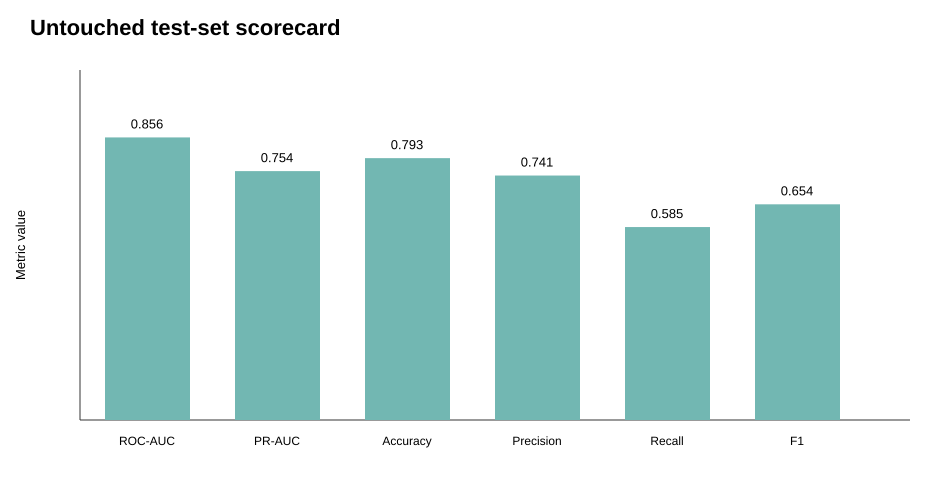

In [ ]:
metric_plot = pd.Series({
    "ROC-AUC": TEST_METRICS["ROC_AUC"],
    "PR-AUC": TEST_METRICS["PR_AUC"],
    "Accuracy": TEST_METRICS["accuracy"],
    "Precision": TEST_METRICS["precision"],
    "Recall": TEST_METRICS["recall"],
    "F1": TEST_METRICS["F1"],
})
metric_plot.plot(kind="bar", figsize=(10, 4))
plt.ylim(0, 1)
plt.title("Test-set scorecard")
plt.ylabel("Score")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

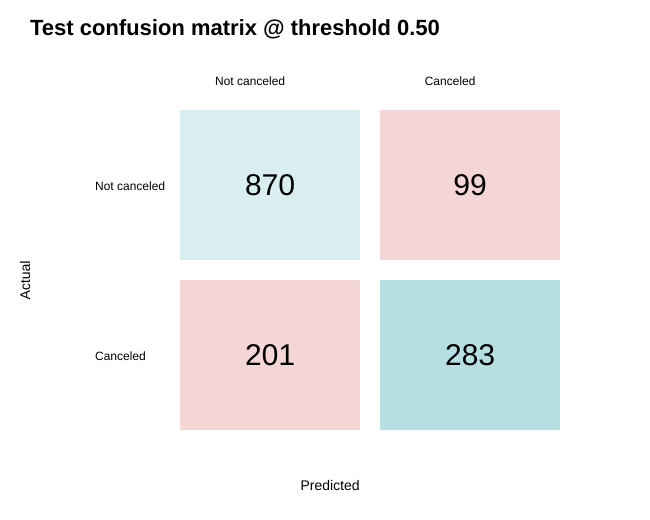

In [ ]:
cm = np.array([
    [TEST_METRICS["TN"], TEST_METRICS["FP"]],
    [TEST_METRICS["FN"], TEST_METRICS["TP"]],
])
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm)
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=14)
ax.set_xticks([0,1], ["Not canceled", "Canceled"])
ax.set_yticks([0,1], ["Not canceled", "Canceled"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Test confusion matrix")
plt.tight_layout()
plt.show()

### What the score means

The model is useful for **ranking** cancellation risk: ROC-AUC is 0.856 and PR-AUC is 0.754.

At the validation-selected 0.50 operating threshold, the model is deliberately not tuned for maximum raw accuracy. It prioritises a commercially usable precision/recall trade-off:
- precision: **74.1%**
- recall: **58.5%**
- F1: **65.4%**

The next section asks the more operational question: does the ranking concentrate cancellations into a manageable high-risk queue?

## 11. Risk-decile and lift analysis

risk_decile  bookings  cancellation_rate  cancellations  average_risk
1                 145             0.9034            131        0.8562
2                 145             0.7241            105        0.6884
3                 145             0.4966             72        0.5251
4                 146             0.4247             62        0.3885
5                 145             0.3034             44        0.2827
6                 145             0.2000             29        0.2053
7                 146             0.1301             19        0.1389
8                 145             0.0828             12        0.0901
9                 145             0.0690             10        0.0517
10                146             0.0000              0        0.0179

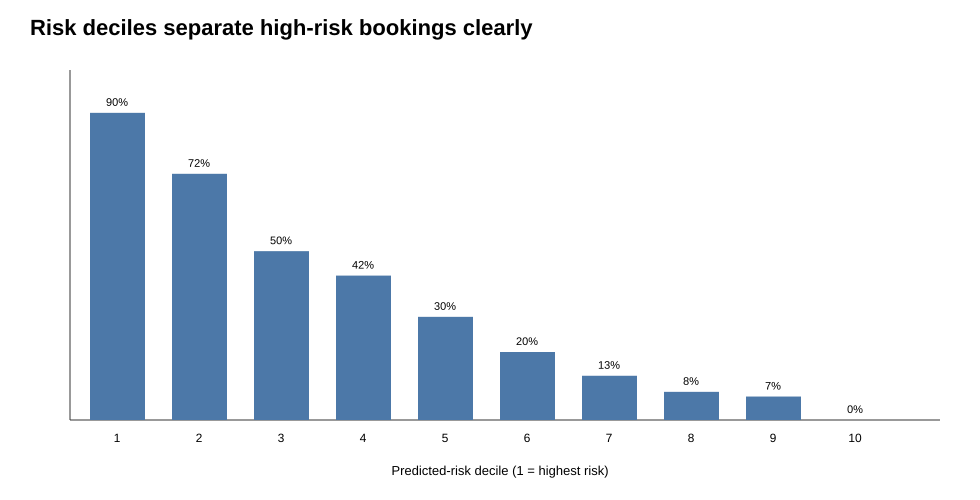

In [ ]:
scored_test = test_df.copy()
scored_test["risk"] = test_probability
scored_test = scored_test.sort_values("risk", ascending=False).reset_index(drop=True)

scored_test["risk_decile"] = (
    np.floor(np.arange(len(scored_test))*10/len(scored_test)).astype(int) + 1
)

deciles = scored_test.groupby("risk_decile").agg(
    bookings=("Booking_ID", "size"),
    cancellation_rate=("is_canceled", "mean"),
    cancellations=("is_canceled", "sum"),
    average_risk=("risk", "mean"),
)
display(deciles.round(4))

deciles["cancellation_rate"].plot(kind="bar", figsize=(10,4))
plt.title("Observed cancellation rate by predicted-risk decile")
plt.ylabel("Cancellation rate")
plt.xlabel("Risk decile: 1 = highest predicted risk")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
total_test_cancellations = int(scored_test["is_canceled"].sum())

def top_fraction_summary(fraction):
    n = int(np.ceil(len(scored_test) * fraction))
    part = scored_test.head(n)
    cancellations = int(part["is_canceled"].sum())
    rate = part["is_canceled"].mean()
    base_rate = scored_test["is_canceled"].mean()
    return {
        "fraction": fraction,
        "bookings": n,
        "cancellations": cancellations,
        "capture": cancellations / total_test_cancellations,
        "cancel_rate": rate,
        "lift": rate / base_rate,
    }

for fraction in [0.10, 0.20, 0.30]:
    print(top_fraction_summary(fraction))

{'fraction': 0.1, 'bookings': 146, 'cancellations': 131, 'capture': 0.2707, 'cancel_rate': 0.8973, 'lift': 2.6936}
{'fraction': 0.2, 'bookings': 291, 'cancellations': 237, 'capture': 0.4897, 'cancel_rate': 0.8144, 'lift': 2.4450}
{'fraction': 0.3, 'bookings': 436, 'cancellations': 308, 'capture': 0.6364, 'cancel_rate': 0.7064, 'lift': 2.1207}

**Operational result:** a revenue team reviewing only the highest-risk **20%** of test bookings would see **49.0% of all cancellations**, with a cancellation rate of **81.4%** in that queue — **2.44×** the population rate.

## 12. Probability calibration audit

In [ ]:
calibration_rows = []
for lower in np.arange(0.0, 1.0, 0.1):
    upper = lower + 0.1
    if upper >= 1.0:
        mask = (test_probability >= lower) & (test_probability <= upper)
    else:
        mask = (test_probability >= lower) & (test_probability < upper)

    if mask.any():
        calibration_rows.append({
            "bin": f"{lower:.1f}-{upper:.1f}",
            "n": int(mask.sum()),
            "mean_predicted": float(test_probability[mask].mean()),
            "actual_rate": float(y_test[mask].mean()),
        })

calibration = pd.DataFrame(calibration_rows)
display(calibration.round(4))

bin      n   mean_predicted  actual_rate
0.0-0.1  392     0.0472          0.0485
0.1-0.2  247     0.1428          0.1457
0.2-0.3  188     0.2464          0.2074
0.3-0.4  134     0.3468          0.4627
0.4-0.5  110     0.4522          0.4091
0.5-0.6   92     0.5520          0.5109
0.6-0.7   86     0.6521          0.6860
0.7-0.8   91     0.7582          0.8352
0.8-0.9   82     0.8554          0.9146
0.9-1.0   31     0.9275          0.8387

## 13. Explainability from standardised coefficients

feature                              coefficient
lead_time                             0.7040
no_of_special_requests              -0.6918
market_segment_type=Offline         -0.5626
lead_time_log                         0.4487
arrival_year                          0.2966
avg_price_per_room                    0.2747
price_per_person                      0.1217
required_car_parking_space           -0.1203
repeated_guest                       -0.1110
market_segment_type=Corporate        -0.0980
booking_value                         0.0898
month_sin                            -0.0801

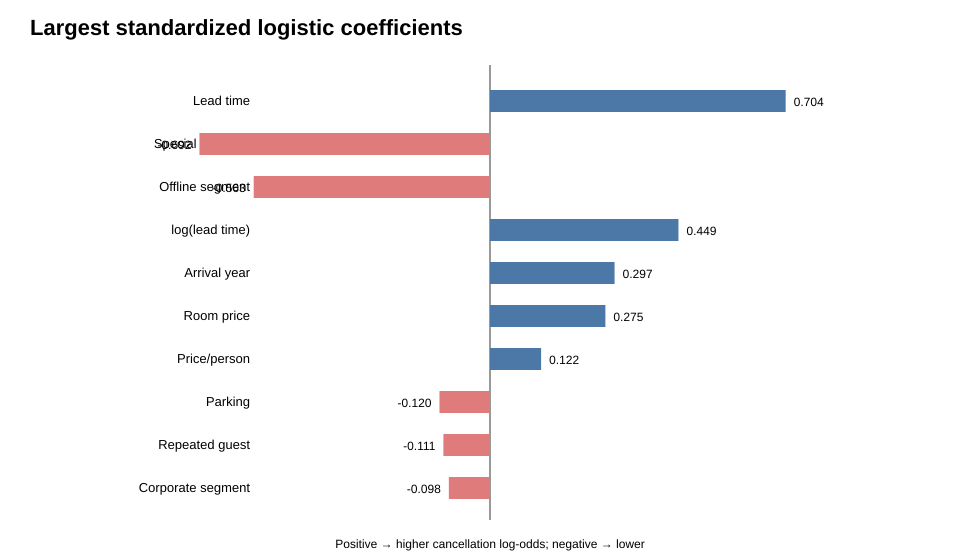

In [ ]:
coef = pd.Series(
    weights[1:],
    index=FEATURE_NAMES,
    name="coefficient"
).sort_values(key=lambda s: s.abs(), ascending=False)

display(coef.head(15).to_frame())

coef.head(10).sort_values().plot(kind="barh", figsize=(9,5))
plt.axvline(0, linewidth=1)
plt.title("Largest standardised logistic coefficients")
plt.xlabel("Coefficient")
plt.tight_layout()
plt.show()

### Interpretation

The largest effects are commercially intuitive but must remain **associational**, not causal:

- longer lead time is strongly associated with higher cancellation risk;
- more special requests are associated with lower cancellation risk;
- repeated guests and corporate bookings tend to be lower risk;
- higher room-price variables contribute some upward risk signal.

Because correlated variables such as raw lead time and log lead time coexist, coefficients should be read as model signals rather than isolated causal effects.

## 14. Revenue intervention scenario

A predictive score only creates value if it changes an action.

We define a transparent, editable scenario for every booking whose predicted risk is at least the operating threshold:

- intervention cost: **5 currency units (CU)** per targeted booking;
- if a targeted booking truly cancels, assume **20% of its booking-value proxy** can be recovered;
- if a targeted booking would not cancel, assign an additional **2 CU nuisance cost**.

These are business assumptions for scenario analysis, **not observed causal uplift**.

Targeted bookings: 382
Coverage: 26.3%
Gross recovered scenario value: 21,867.66 CU
Intervention cost: 1,910.00 CU
False-positive nuisance cost: 198.00 CU
Net scenario value: 19,759.66 CU
Actual canceled booking value in test: 179,230.37 CU

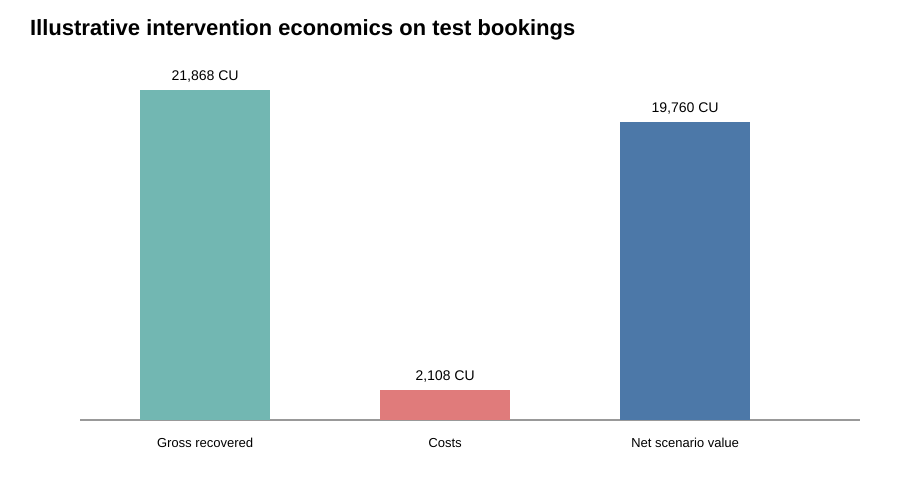

In [ ]:
INTERVENTION_COST = 5.0
FALSE_POSITIVE_NUISANCE_COST = 2.0
RECOVERY_RATE = 0.20

scenario = test_df.copy()
scenario["risk"] = test_probability
scenario["targeted"] = scenario["risk"] >= OPERATING_THRESHOLD
scenario["booking_value"] = (
    scenario["avg_price_per_room"] *
    (scenario["no_of_weekend_nights"] + scenario["no_of_week_nights"]).clip(lower=1)
)

targeted = scenario["targeted"]
true_cancel = scenario["is_canceled"].eq(1)

gross_recovered = (
    scenario.loc[targeted & true_cancel, "booking_value"].sum()
    * RECOVERY_RATE
)
intervention_cost = targeted.sum() * INTERVENTION_COST
nuisance_cost = (
    (targeted & ~true_cancel).sum()
    * FALSE_POSITIVE_NUISANCE_COST
)
net_value = gross_recovered - intervention_cost - nuisance_cost

print("Targeted bookings:", int(targeted.sum()))
print(f"Coverage: {targeted.mean():.1%}")
print(f"Gross recovered scenario value: {gross_recovered:,.2f} CU")
print(f"Intervention cost: {intervention_cost:,.2f} CU")
print(f"False-positive nuisance cost: {nuisance_cost:,.2f} CU")
print(f"Net scenario value: {net_value:,.2f} CU")
print(f"Actual canceled booking value in test: {scenario.loc[true_cancel, 'booking_value'].sum():,.2f} CU")

## 15. Decision engine

A practical deployment would not simply label bookings "cancel / not cancel." It would create an ordered work queue:

1. score every active booking;
2. rank by predicted cancellation risk;
3. multiply risk by booking-value exposure;
4. prioritise high-risk, high-value reservations;
5. choose intervention intensity by segment and cost;
6. measure real causal uplift using a controlled experiment;
7. recalibrate / retrain as booking behaviour changes.

In [ ]:
scored_test["booking_value"] = (
    scored_test["avg_price_per_room"] *
    (scored_test["no_of_weekend_nights"] + scored_test["no_of_week_nights"]).clip(lower=1)
)
scored_test["expected_value_at_risk"] = (
    scored_test["risk"] * scored_test["booking_value"]
)

priority_queue = scored_test[[
    "Booking_ID",
    "market_segment_type",
    "lead_time",
    "avg_price_per_room",
    "total_nights",
    "risk",
    "booking_value",
    "expected_value_at_risk",
    "booking_status",
]].sort_values("expected_value_at_risk", ascending=False)

display(priority_queue.head(15))

## 16. Integrity checks

In [ ]:
assert len(df) == 7255
assert len(train_df) == 4352
assert len(val_df) == 1450
assert len(test_df) == 1453
assert set(train_idx).isdisjoint(val_idx)
assert set(train_idx).isdisjoint(test_idx)
assert set(val_idx).isdisjoint(test_idx)
assert len(FEATURE_NAMES) == 35
assert 0 <= test_probability.min() <= test_probability.max() <= 1
assert round(TEST_METRICS["ROC_AUC"], 3) == 0.856
assert round(TEST_METRICS["PR_AUC"], 3) == 0.754
print("All Project 29 integrity checks passed ✅")

All Project 29 integrity checks passed ✅

## 17. Final solution

### Model result
On the untouched 1,453-booking test split:
- **ROC-AUC:** 0.8563
- **PR-AUC:** 0.7542
- **Accuracy:** 79.35%
- **Precision:** 74.08%
- **Recall:** 58.47%
- **F1:** 65.36%
- **Brier score:** 0.1413

### Ranking result
The highest-risk 20% of bookings contains:
- **49.0% of all test cancellations**
- an **81.4% cancellation rate**
- **2.44× lift** over the population rate

### Commercial solution
The best use of this system is **prioritised cancellation-risk intervention**, not blanket restrictions on every customer.

A hotel could:
- ask the highest-risk / highest-value bookings for confirmation or deposits;
- use lower-friction reminders for medium-risk bookings;
- protect loyal / corporate customers from unnecessary friction;
- evaluate the real intervention effect using A/B testing.

Under the explicit illustrative assumptions used here, targeting 26.3% of test bookings produces a modelled **19,759.66 CU net scenario value**. This is a scenario calculation, not proven causal revenue uplift.

In [ ]:
print("PROJECT 29 — FINAL EXECUTIVE SUMMARY")
print("=" * 68)
print("Real booking rows analysed: 7,255")
print("Population cancellation rate: 33.3%")
print("Canceled booking-value proxy: 873,707.81 CU")
print()
print("Untouched test:")
print("ROC-AUC: 0.8563 | PR-AUC: 0.7542")
print("Accuracy: 79.35% | Precision: 74.08% | Recall: 58.47% | F1: 65.36%")
print()
print("Top 20% risk queue:")
print("49.0% of cancellations captured | 2.44x lift")
print()
print("Illustrative intervention:")
print("26.3% of bookings targeted | 19,759.66 CU net scenario value")
print()
print("SOLUTION: use calibrated risk + booking value to prioritise")
print("revenue-protection actions, then validate actual uplift experimentally.")

PROJECT 29 — FINAL EXECUTIVE SUMMARY
Real booking rows analysed: 7,255
Population cancellation rate: 33.3%
Canceled booking-value proxy: 873,707.81 CU

Untouched test:
ROC-AUC: 0.8563 | PR-AUC: 0.7542
Accuracy: 79.35% | Precision: 74.08% | Recall: 58.47% | F1: 65.36%

Top 20% risk queue:
49.0% of cancellations captured | 2.44x lift

Illustrative intervention:
26.3% of bookings targeted | 19,759.66 CU net scenario value

SOLUTION: use calibrated risk + booking value to prioritise
revenue-protection actions, then validate actual uplift experimentally.

## 18. Limitations and next production steps

- The fixed modelling file is a public 7,255-row split, not the entire 36,275-row source dataset.
- The split is deterministic and stratified, but not a true future-period deployment test.
- `avg_price_per_room × nights` is a value proxy, not audited recognised revenue.
- Coefficients are associational and should not be interpreted causally.
- The intervention assumptions are illustrative; actual uplift requires experimentation.
- Real deployment should add property/room inventory, channel cost, payment/deposit state, customer consent, seasonality, no-show status and live availability.
- Production monitoring should cover discrimination, calibration, segment fairness, data drift and intervention ROI.

**CV-ready line:** Built an interpretable hotel cancellation-risk and revenue-protection engine on 7,255 real reservations, achieving 0.856 ROC-AUC and 0.754 PR-AUC, with risk ranking that captured 49% of cancellations in the highest-risk 20% of bookings and an explicit intervention-value framework.